In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

### Load data classified by source 

In [2]:
human_known = pd.read_csv('manually_classified_human_samples.csv', index_col=0)

/var/folders/nh/_pzp_lps21jf91jy0p779fvm0000gn/T/ipykernel_65958/3106772147.py:1: DtypeWarning: Columns (12,13) have mixed types. Specify dtype option on import or set low_memory=False.
  human_known = pd.read_csv('manually_classified_human_samples.csv', index_col=0)


Some accessions are included multiple times; but the duplicates are always classified in the same subcategory, so I will just drop the duplicates.

In [3]:
human_known['Assembly Accession'].nunique(), human_known['Assembly Accession'].shape

(89483, (103459,))

In [4]:
human_known = human_known.drop_duplicates('Assembly Accession')
human_known['human_subcategory'].value_counts()

human_subcategory
unknown                      31763
gastrointestinal             21029
respiratory                  15065
blood                        10885
urine                         4172
other                         3444
skin                          1260
oral                           924
female reproductive tract      518
non-human                      423
Name: count, dtype: int64

In [5]:
human_known.shape

(89483, 16)

### Load predictions

In [6]:
predictions = pd.read_csv('gemma-2-9b-it_classifications.csv', header=None, sep='|')
predictions.columns = ['isolate_source','human_subcategory']

predictions['human_subcategory'] = predictions['human_subcategory'].str.lower().replace('.','').str.replace('\t','').str.strip(' ')
# .str.replace('.', '')


to_replace = {
                'eye':'other',
                'heart':'other',
              'abdominal':'other',
              'male reproductive tract':'other',
              'stool':'gastrointestinal',
              'spinal':'other',
              'liver':'other',
              'joint':'other',
                'peritoneal':'other',
              'nasal':'respiratory',
              'nasal.':'respiratory',
              'urone':'urine',
             'input:':'unknown',

              }
              
              
            
for old, new in to_replace.items():
    predictions['human_subcategory'] = predictions['human_subcategory'].replace(old,new)

predictions.value_counts('human_subcategory')

human_subcategory
skin                         611
respiratory                  505
other                        461
gastrointestinal             429
unknown                      344
blood                        268
oral                         180
urine                        112
female reproductive tract     90
non-human                     28
Name: count, dtype: int64

In [7]:
source_to_category = predictions.set_index('isolate_source')['human_subcategory'].to_dict()

human_unknown = pd.read_csv('unclassified_human_samples.csv', index_col=0)
human_unknown['human_subcategory'] = human_unknown['Assembly BioSample Isolation source'].map(source_to_category)
human_unknown['human_subcategory'].value_counts()

human_subcategory
unknown                      1905
skin                         1674
respiratory                  1593
gastrointestinal             1441
other                        1350
blood                         678
urine                         582
oral                          489
female reproductive tract     320
non-human                     110
Name: count, dtype: int64

In [8]:
human_unknown.drop_duplicates(['Assembly Accession', 'human_subcategory']).shape, human_unknown.drop_duplicates(['Assembly Accession']).shape

((9200, 16), (9200, 16))

In [9]:
human_unknown = human_unknown.drop_duplicates(['Assembly Accession', 'human_subcategory'])

### Merge predictions

In [10]:
merged = pd.concat([human_known, human_unknown])

merged_filt = merged[~(merged['human_subcategory'].isna()) &
                     ~(merged['human_subcategory'].isin(['unknown','non-human']))]
merged_filt['human_subcategory'].value_counts()

human_subcategory
gastrointestinal             22355
respiratory                  16556
blood                        11522
urine                         4709
other                         4597
skin                          2696
oral                          1366
female reproductive tract      777
Name: count, dtype: int64

In [11]:
merged[(merged['human_subcategory'].isna()) |
                     (merged['human_subcategory'].isin(['unknown']))].shape

(33573, 16)

In [12]:
merged[(merged['human_subcategory'] == 'non-human')].shape

(532, 16)

In [13]:
merged_filt['human_subcategory'].value_counts(normalize=True)

human_subcategory
gastrointestinal             0.346171
respiratory                  0.256372
blood                        0.178420
urine                        0.072920
other                        0.071185
skin                         0.041748
oral                         0.021153
female reproductive tract    0.012032
Name: proportion, dtype: float64

### Manually verifying/re-annotating genomes for 6 most prevalent species

In [14]:
base_dir = '/Users/cdubin/Library/CloudStorage/Box-Box/VMGC_cervical_dysplasia_paper/code/'

In [15]:
species = pd.read_csv(f'{base_dir}compare_VMGC_GTDB/select_species_for_analysis/shared_species_for_analysis.csv', index_col=0)
#reorder so lactobacillus species are together
species_list = ['Lactobacillus crispatus', 'Lactobacillus iners', 'Lactobacillus jensenii', 'Lactobacillus gasseri','Bifidobacterium vaginale', 'Fannyhessea vaginae',]
species = species.loc[species_list]
vmgc_species_list = species['species_id_VMGC'].tolist()
gtdb_species_list = species['species_id_GTDB'].tolist()


In [16]:
ncbi_info = pd.read_csv('NCBI_genome_info.tsv', sep='\t')
ncbi_non_human = ncbi_info[~ncbi_info['Assembly Accession'].isin(merged['Assembly Accession'])]
ncbi_non_human.shape

/var/folders/nh/_pzp_lps21jf91jy0p779fvm0000gn/T/ipykernel_65958/1494396413.py:1: DtypeWarning: Columns (2,5,7,8) have mixed types. Specify dtype option on import or set low_memory=False.
  ncbi_info = pd.read_csv('NCBI_genome_info.tsv', sep='\t')


(186090, 14)

In [17]:
midas_genomes = pd.read_csv(f'{base_dir}/GTDB/GTDB_genomes_in_MIDAS.tsv', sep='\t', index_col=0)
midas_genomes = midas_genomes[midas_genomes['species'].isin(gtdb_species_list)]

to_merge = pd.concat([merged,ncbi_non_human])
midas_ann = to_merge[to_merge['Assembly Accession'].isin(midas_genomes.index.tolist())]
# midas_genomes = midas_genomes.merge(to_merge, left_index=True, right_index=True, how='left')

for m in midas_genomes.index:
    if m not in midas_ann['Assembly Accession'].values:
                print(m)

midas_ann['species'] = midas_ann['Assembly Accession'].map(midas_genomes['species'])
midas_ann = midas_ann.sort_values(['species','Assembly Accession'])
midas_ann.to_csv('six_species_origins.csv')

/var/folders/nh/_pzp_lps21jf91jy0p779fvm0000gn/T/ipykernel_65958/2704982013.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  midas_ann['species'] = midas_ann['Assembly Accession'].map(midas_genomes['species'])


I manually annotated the above file for genomes with unknown origins

In [18]:
!pwd

/Users/cdubin/Library/CloudStorage/Box-Box/VMGC_cervical_dysplasia_paper/code/GTDB/classify_GTDB_sources


In [19]:
midas_ann_full = pd.read_excel('six_species_origins.xlsx', index_col=0)
midas_ann_full['species_name'] = midas_ann_full['species'].map(species.reset_index().set_index('species_id_GTDB')['species'])
midas_ann_full = midas_ann_full.drop_duplicates('Assembly Accession')

### Load VMGC metadata

In [20]:
vmgc_metadata = pd.read_csv(f'{base_dir}/VMGC/VMGC_db_build/VMGC_orig_files/VMGC_prokaryote_MAG.info', sep='\t')
vmgc_genomes = pd.read_csv(f'{base_dir}/VMGC/VMGC_db_build/genomes.tsv', sep='\t')
vmgc_genomes = vmgc_genomes[vmgc_genomes['species'].isin(vmgc_species_list)]
vmgc_genomes['species_name'] = vmgc_genomes['species'].map(species.reset_index().set_index('species_id_VMGC')['species'])

vmgc_species_counts = vmgc_genomes.value_counts('species_name')
vmgc_genomes

,genome,species,representative,genome_is_representative,fasta_path,species_name
4,GCF_000439915.2,611554,GCF_000439915.2,1,/wynton/group/sirota/clairedubin/VMGC_db/VMGC_...,Lactobacillus gasseri
8,SRR17284223.mbin.1,240891,SRR17284223.mbin.1,1,/wynton/group/sirota/clairedubin/VMGC_db/VMGC_...,Lactobacillus iners
9,SRR10258542.mbin.1,240891,SRR17284223.mbin.1,0,/wynton/group/sirota/clairedubin/VMGC_db/VMGC_...,Lactobacillus iners
12,MG329.mbin.1,240891,SRR17284223.mbin.1,0,/wynton/group/sirota/clairedubin/VMGC_db/VMGC_...,Lactobacillus iners
17,P10709414.mbin.1,240891,SRR17284223.mbin.1,0,/wynton/group/sirota/clairedubin/VMGC_db/VMGC_...,Lactobacillus iners
...,...,...,...,...,...,...
19527,ERR10897803.mbin.2,988598,GCF_000162255.1,0,/wynton/group/sirota/clairedubin/VMGC_db/VMGC_...,Lactobacillus crispatus
19529,SRR17284198.sbin.3,988598,GCF_000162255.1,0,/wynton/group/sirota/clairedubin/VMGC_db/VMGC_...,Lactobacillus crispatus
19531,MG886.mbin.2,240891,SRR17284223.mbin.1,0,/wynton/group/sirota/clairedubin/VMGC_db/VMGC_...,Lactobacillus iners
19532,ERR10897653.mbin.1,988598,GCF_000162255.1,0,/wynton/group/sirota/clairedubin/VMGC_db/VMGC_...,Lactobacillus crispatus


In [21]:
category_colors = {

    'female reproductive tract': 'skyblue',
    'gastrointestinal tract': 'blue',
    'urinary tract': 'blueviolet',
    'other (human origin)': 'indigo',
    'non-human': 'hotpink',
    'unknown':'silver'
}

In [22]:
midas_ann_full['human_subcategory'].value_counts()

human_subcategory
female reproductive tract    130
urine                         61
non-human                     50
gastrointestinal              14
unknown                        9
other                          5
respiratory                    4
oral                           2
Name: count, dtype: int64

In [23]:
midas_ann_full['category_to_plot'] = midas_ann_full['human_subcategory'].replace('oral','other').replace('respiratory','other')
midas_ann_full['category_to_plot']  = midas_ann_full['category_to_plot'].replace('other','other (human origin)')
midas_ann_full['category_to_plot']  = midas_ann_full['category_to_plot'].replace('urine','urinary tract')
midas_ann_full['category_to_plot']  = midas_ann_full['category_to_plot'].replace('gastrointestinal','gastrointestinal tract')

In [24]:
midas_ann_full['category_to_plot'].value_counts()

category_to_plot
female reproductive tract    130
urinary tract                 61
non-human                     50
gastrointestinal tract        14
other (human origin)          11
unknown                        9
Name: count, dtype: int64

In [25]:

plt.style.use('tableau-colorblind10')
plt.rcParams.update({'font.size': 18, 'font.family':'Arial'})

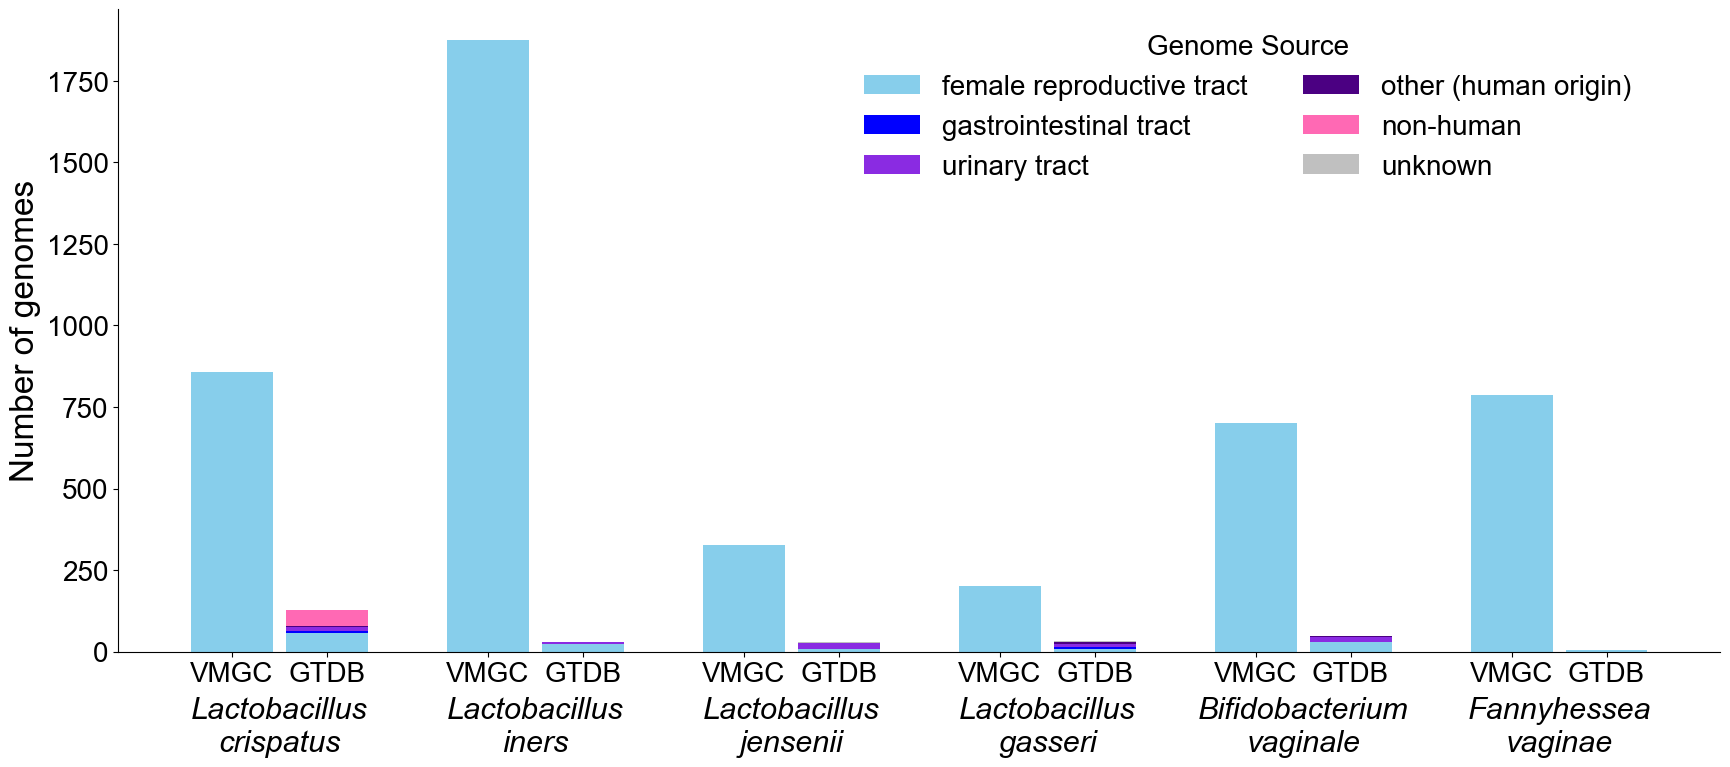

In [30]:

species_counts = midas_ann_full['species_name'].value_counts()

df_filtered = midas_ann_full.copy()
counts = df_filtered.groupby(['species_name', 'category_to_plot']).size().reset_index(name='counts')
counts_pivot = counts.pivot(index='species_name', columns='category_to_plot', values='counts').fillna(0)
counts_pivot = counts_pivot[[c for c in category_colors.keys() if c in counts_pivot.columns]].loc[species_list]
vmgc_df = pd.Series(vmgc_species_counts).reindex(counts_pivot.index).fillna(0).loc[species_list]

# Plotting
fig, ax = plt.subplots(figsize=(18, 8))
bar_width = 0.37
x = range(len(counts_pivot.index))


# VMGC bars (left)
ax.bar(
    [xi - bar_width / 2 for xi in x],
    vmgc_df.values,
    width=bar_width-0.05,
    color=category_colors['female reproductive tract'],
)


# GTDB bars (right, stacked)
bottom = [0] * len(x)
for cat in counts_pivot.columns:
    ax.bar(
        [xi + bar_width / 2 for xi in x],
        counts_pivot[cat].values,
        bottom=bottom,
        width=bar_width-0.05,
        color=category_colors[cat],
        label=cat
    )
    bottom = [b + h for b, h in zip(bottom, counts_pivot[cat].values)]

# Custom x-ticks: interleave VMGC/GTDB and species names
xticks = []
xticklabels = []
for xi, species in zip(x, counts_pivot.index):
    xticks.extend([xi - bar_width / 2, xi + bar_width / 2])
    xticklabels.extend(['VMGC', 'GTDB'])

ax.set_xticks(xticks)
ax.set_xticklabels(xticklabels, rotation=0, fontsize=20)
ax.spines[['right','top']].set_visible(False)

# Add species names below bar pairs
for xi, species in zip(x, counts_pivot.index):
    ax.text(xi, -0.07, species.replace(' ', '\n'), ha='center', va='top', rotation=0, fontsize=22, transform=ax.get_xaxis_transform(), fontstyle='italic')



ax.set_ylabel('Number of genomes', fontsize=24)
ax.tick_params(axis='y', which='major', labelsize=20)

ax.legend(title='Genome Source', bbox_to_anchor=(.45, 1), loc='upper left',
 frameon=False, ncols=2, fontsize=20, title_fontsize=20)
plt.tight_layout()
fig_dir = '/Users/cdubin/Box/VMGC_cervical_dysplasia_paper/figures/'
plt.savefig(f'{fig_dir}/figure_2B.png', format='png', dpi=600, bbox_inches="tight")
plt.show()


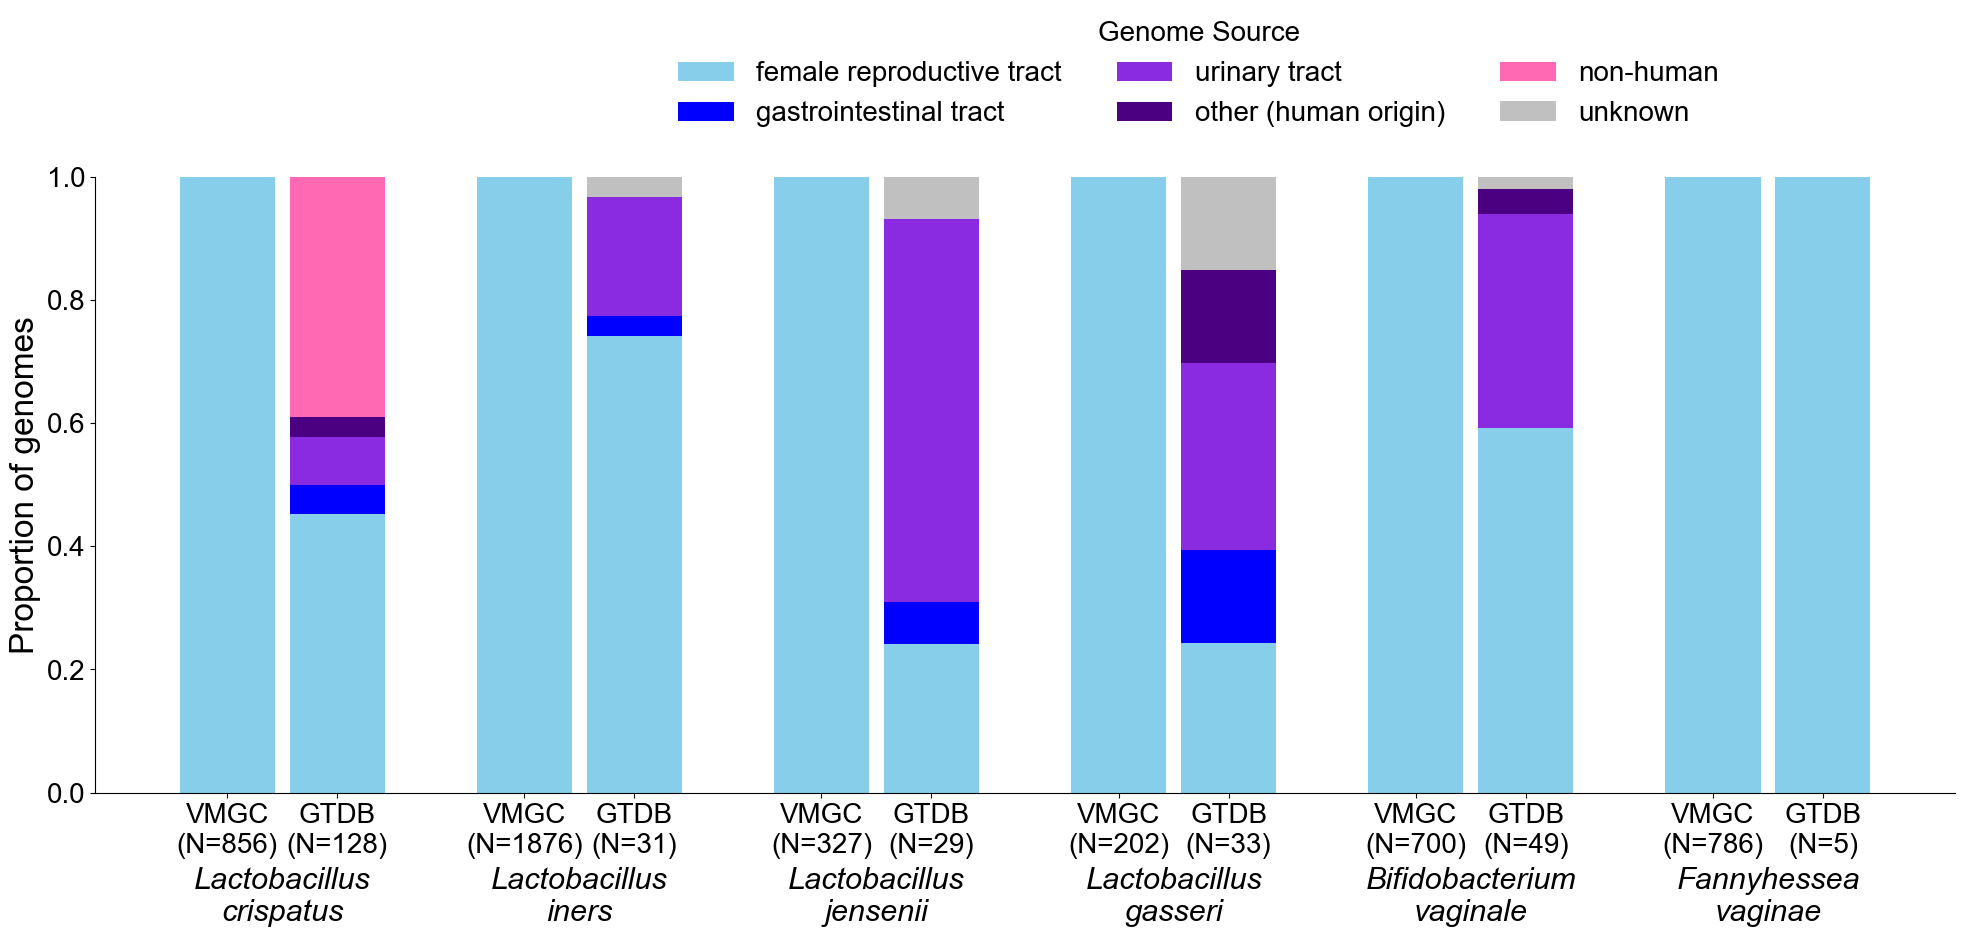

In [32]:
species_counts = midas_ann_full['species_name'].value_counts()

df_filtered = midas_ann_full.copy()
counts = df_filtered.groupby(['species_name', 'category_to_plot']).size().reset_index(name='counts')
counts_pivot = counts.pivot(index='species_name', columns='category_to_plot', values='counts').fillna(0)
counts_pivot = counts_pivot[[c for c in category_colors.keys() if c in counts_pivot.columns]].loc[species_list]

# Convert to proportions
counts_pivot_prop = counts_pivot.div(counts_pivot.sum(axis=1), axis=0)

vmgc_df = pd.Series(vmgc_species_counts).reindex(counts_pivot.index).fillna(0).loc[species_list]
# VMGC is all one category, so proportion is always 1.0
vmgc_df_prop = pd.Series([1.0] * len(vmgc_df), index=vmgc_df.index)

# Calculate total counts for each bar
vmgc_totals = vmgc_df.values
gtdb_totals = counts_pivot.sum(axis=1).values

# Plotting
fig, ax = plt.subplots(figsize=(24, 8))
bar_width = 0.37
x = range(len(counts_pivot_prop.index))

# VMGC bars (left) - all one color, proportion = 1.0
ax.bar(
    [xi - bar_width / 2 for xi in x],
    vmgc_df_prop.values,
    width=bar_width-0.05,
    color=category_colors['female reproductive tract'],
    # label='female reproductive tract'
)

# GTDB bars (right, stacked) - using proportions
bottom = [0] * len(x)
for cat in counts_pivot_prop.columns:
    ax.bar(
        [xi + bar_width / 2 for xi in x],
        counts_pivot_prop[cat].values,
        bottom=bottom,
        width=bar_width-0.05,
        color=category_colors[cat],
        label=cat
    )
    bottom = [b + h for b, h in zip(bottom, counts_pivot_prop[cat].values)]

# Custom x-ticks: interleave VMGC/GTDB and species names with N counts
xticks = []
xticklabels = []
for i, (xi, species) in enumerate(zip(x, counts_pivot_prop.index)):
    xticks.extend([xi - bar_width / 2, xi + bar_width / 2])
    xticklabels.extend([f'VMGC\n(N={int(vmgc_totals[i])})', f'GTDB\n(N={int(gtdb_totals[i])})'])

ax.set_xticks(xticks)
ax.set_xticklabels(xticklabels, rotation=0, fontsize=20)
ax.spines[['right','top']].set_visible(False)

# Add species names below bar pairs
for xi, species in zip(x, counts_pivot_prop.index):
    ax.text(xi, -0.12, species.replace(' ', '\n'), ha='center', va='top', rotation=0, fontsize=22, transform=ax.get_xaxis_transform(), fontstyle='italic')

ax.set_ylabel('Proportion of genomes', fontsize=24)
ax.set_ylim(0, 1)  # Set y-axis to 0-1 for proportions
ax.tick_params(axis='y', which='major', labelsize=20)

ax.legend(title='Genome Source', bbox_to_anchor=(0.3, 1.04), loc='lower left',
 frameon=False, ncols=3, fontsize=20, title_fontsize=20)

fig_dir = '/Users/cdubin/Box/VMGC_cervical_dysplasia_paper/figures/'
plt.savefig(f'{fig_dir}/figure_S4.png', format='png', dpi=600, bbox_inches="tight")
plt.show()

### For poster

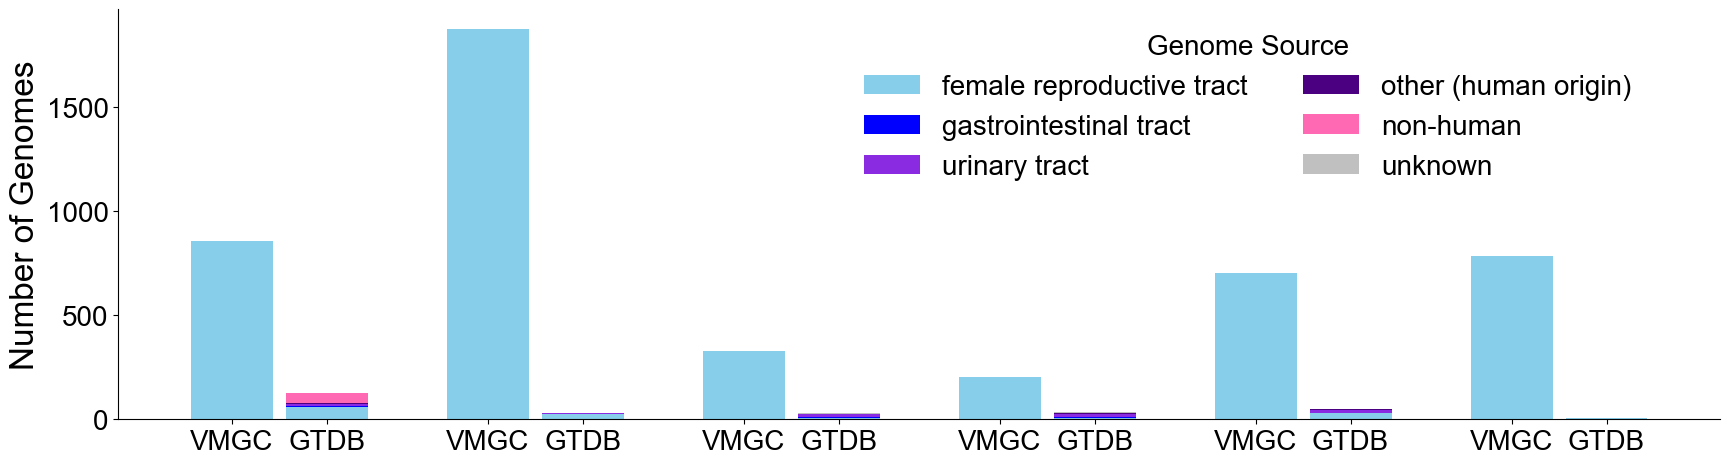

In [35]:

species_counts = midas_ann_full['species_name'].value_counts()

df_filtered = midas_ann_full.copy()
counts = df_filtered.groupby(['species_name', 'category_to_plot']).size().reset_index(name='counts')
counts_pivot = counts.pivot(index='species_name', columns='category_to_plot', values='counts').fillna(0)
counts_pivot = counts_pivot[[c for c in category_colors.keys() if c in counts_pivot.columns]].loc[species_list]
vmgc_df = pd.Series(vmgc_species_counts).reindex(counts_pivot.index).fillna(0).loc[species_list]

# Plotting
fig, ax = plt.subplots(figsize=(18, 5))
bar_width = 0.37
x = range(len(counts_pivot.index))


# VMGC bars (left)
ax.bar(
    [xi - bar_width / 2 for xi in x],
    vmgc_df.values,
    width=bar_width-0.05,
    color=category_colors['female reproductive tract'],
)


# GTDB bars (right, stacked)
bottom = [0] * len(x)
for cat in counts_pivot.columns:
    ax.bar(
        [xi + bar_width / 2 for xi in x],
        counts_pivot[cat].values,
        bottom=bottom,
        width=bar_width-0.05,
        color=category_colors[cat],
        label=cat
    )
    bottom = [b + h for b, h in zip(bottom, counts_pivot[cat].values)]

# Custom x-ticks: interleave VMGC/GTDB and species names
xticks = []
xticklabels = []
for xi, species in zip(x, counts_pivot.index):
    xticks.extend([xi - bar_width / 2, xi + bar_width / 2])
    xticklabels.extend(['VMGC', 'GTDB'])

ax.set_xticks(xticks)
ax.set_xticklabels(xticklabels, rotation=0, fontsize=20)
ax.spines[['right','top']].set_visible(False)

# Add species names below bar pairs
# for xi, species in zip(x, counts_pivot.index):
    # ax.text(xi, -0.07, species.replace(' ', '\n'), ha='center', va='top', rotation=0, fontsize=22, transform=ax.get_xaxis_transform(), fontstyle='italic')



ax.set_ylabel('Number of Genomes', fontsize=24)
ax.tick_params(axis='y', which='major', labelsize=20)

ax.legend(title='Genome Source', bbox_to_anchor=(.45, 1), loc='upper left',
 frameon=False, ncols=2, fontsize=20, title_fontsize=20)
plt.tight_layout()
# fig_dir = '/Users/cdubin/Box/VMGC_cervical_dysplasia_paper/figures/'
plt.savefig(f'/Users/cdubin/Desktop/figure_2B.png', format='png', dpi=600, bbox_inches="tight")
plt.show()
